In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"social_ads.csv"
file_path = os.path.join(base_path,file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 1단계, 데이터 전처리

In [4]:
# User ID: 삭제
# 수치형: Age, EstimatedSalary
# 분류형: User ID, Gender, Purchased

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
ads_df = df.drop("User ID", axis=1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [7]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

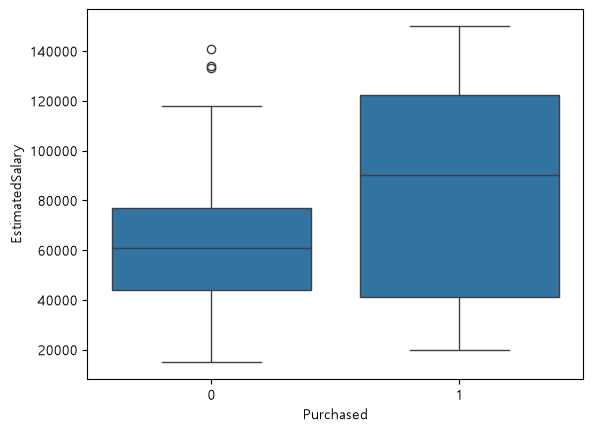

In [8]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

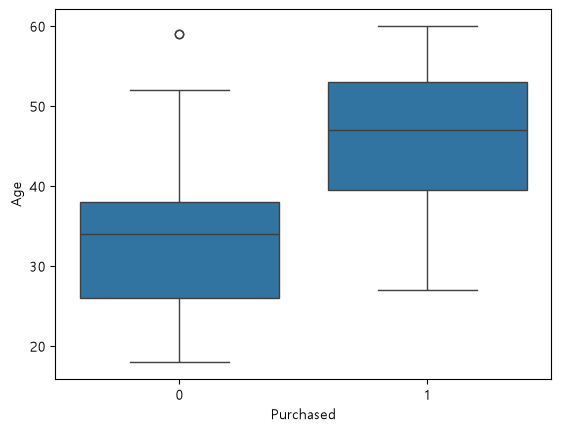

In [9]:
sns.boxplot(ads_df, x="Purchased", y="Age")
plt.show()
# 나이가 많은 사람들이 구매를 많이 하는것이 보임

In [10]:
ads_df.head(1)
# > 성별을 인코딩 해야할거같음!!

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0


In [11]:
ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int, drop_first=True)

In [12]:
ads_df.head()

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [13]:
X = ads_df.drop("Purchased", axis=1)
print(X.head())
y = ads_df["Purchased"]
print(y.head())

   Age  EstimatedSalary  Gender_Male
0   19            19000            1
1   35            20000            1
2   26            43000            0
3   27            57000            0
4   19            76000            1
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유 -> 데이터셋을 나누기 전에 전체 데이터를 스케일링하면
  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [14]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 3) (80, 3) (320,) (80,)


In [15]:
# 표준화
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## 2단계, 모델 준비

In [16]:
# salary 연봉 데이터
X_train_salary = X_train_scaled[:, [1]]
X_test_salary = X_test_scaled[:, [1]]

In [17]:
# 선형희귀 모델(weight * x) + bias
# weight: 가중치
# bias: 절편
lr = LinearRegression()

In [18]:
lr.fit(X_train_salary, y_train)

LinearRegression()

In [19]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620512


## 결론 : 쓰레기모델임

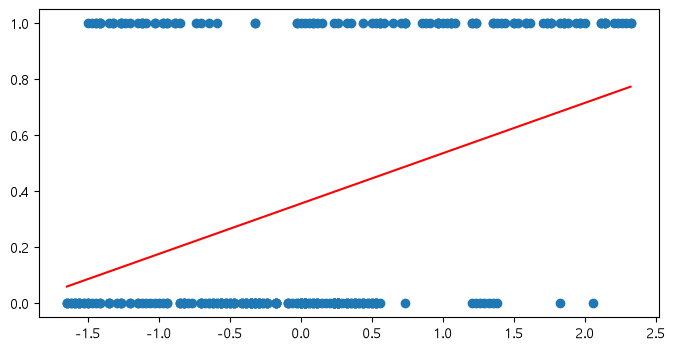

In [20]:
plt.figure(figsize=(8,4))
plt.scatter(X_train_salary, y_train)
x_line = np.linspace(X_train_salary.min(), X_train_salary.max(), 100).reshape(-1,1)
y_line = lr.predict(x_line)
plt.plot(x_line, y_line, color="red")
plt.show()

## 모델준비

In [21]:
lr = LogisticRegression()

## 모델학습

In [22]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [23]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

## 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미합니다.
  현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측 능력이 크게 떨어질 수 있습니다.
  이런 현상을 과적합이라고 합니다.

In [24]:
print(f"훈련 데이터 점수 : {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수 : {accuracy_score(y_pred, y_test)}")

훈련 데이터 점수 : 0.853125
테스트 데이터 점수 : 0.7875


In [25]:
lr.coef_[0]

array([2.39487483, 1.16153043, 0.37388932])

In [26]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
0,Age,2.394875
1,EstimatedSalary,1.161530
2,Gender_Male,0.373889


In [27]:
"""
    소셜에서 상품을 구매할 때에는 연봉보다는 나이가 구매할 때 영향을 많이 끼친 것으로 파악된다.
"""
None

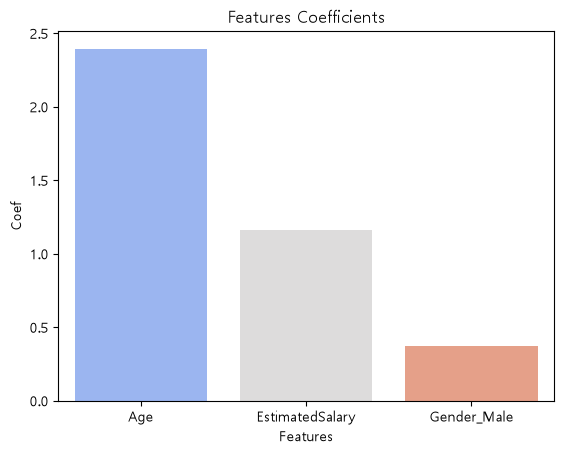

In [28]:
sns.barplot(coef_df, x="Features", y="Coef",hue="Features", palette="coolwarm")
plt.title("Features Coefficients")
plt.show()

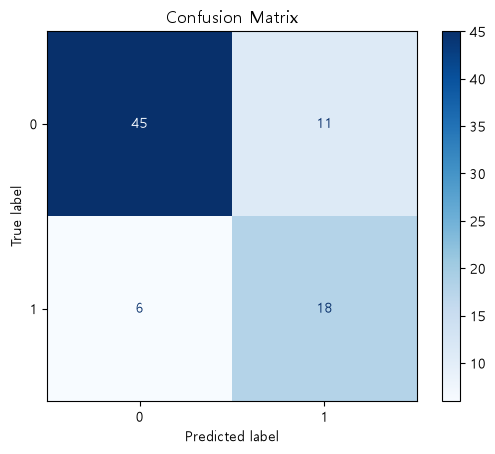

In [29]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 | 비고 |
| :--- | :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 | **학습 시 제거 (`df.drop`)** |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 | 입력 특성 (Feature) |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 | 입력 특성 (Feature) |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) | 입력 특성 (Feature) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 | 입력 특성 (Feature) |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 | 입력 특성 (Feature) |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) | 입력 특성 (Feature) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) | 입력 특성 (Feature) |
| **`Chance of Admit`** | 실수 (Float) | $0.34 \sim 0.97$ | 합격 가능성 확률 ($0.0 \sim 1.0$) | **타깃 변수 (Target)** |

In [30]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path,file_name)

In [31]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0
